In [1]:
import json
import os

os.chdir("..")

In [2]:
from cluster_intrep_repo.utils import DOMAIN_PHRASES

In [4]:
# def make_mean_reprs_layer(layer: int):
all_representations = {}

for i in range(1, 16):
    with open(f"multilayer_representations/multilayer_7k/mystery_{i}/mean_reprs_mystery_{i}_multi_layer.json") as f:
        all_representations[f"mystery_{i}"] = json.load(f)

In [5]:
all_representations["mystery_1"][str(44)]["mean_reprs"].keys()

dict_keys(['attack', 'succumb', 'overcome', 'feast', 'planet', 'province', 'harmony', 'craves', 'pain'])

In [6]:
action_phrases = [
    "attack",
    "succumb",
    "overcome",
    "feast"
]

In [7]:
import numpy as np
records = []

layer = 44

for layer in [1, 5, 10, 20, 30, 40, 44]:
    for i in range(1, 16):
        for phrase in action_phrases:
                mapped_phrase = DOMAIN_PHRASES[f"mystery_{i}"]["actions"][phrase]  
                records.append({
                    "repr": np.array(all_representations[f"mystery_{i}"][str(layer)]["mean_reprs"][mapped_phrase]) - np.array(all_representations[f"mystery_{i}"][str(layer)]["mean_actions"]),
                    "phrase": phrase,
                    "mystery_num": i,
                    "layer": layer
                })

Layer 10 - Total variance explained: 8.8%
Layer 40 - Total variance explained: 35.3%
Plot saved as 'pca_layer_analysis_7k_short.pdf'


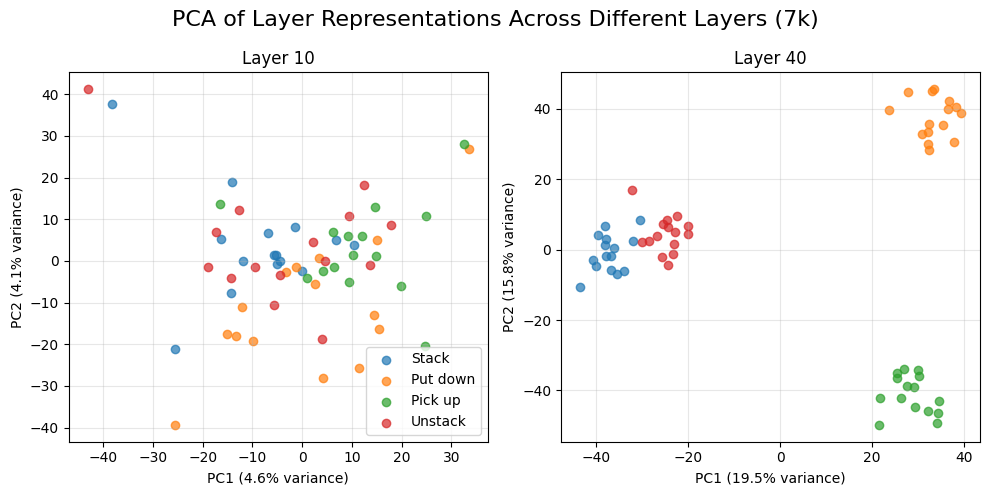

In [11]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

phrases_mapping = {
    "attack": "Pick up",
    "succumb": "Put down",
    "overcome": "Stack",
    "feast": "Unstack"
}

# Define layers to analyze
layers = [10, 40]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('PCA of Layer Representations Across Different Layers (7k)', fontsize=16)

for idx, layer in enumerate(layers):
    # Filter records for current layer
    layer_records = [r for r in records if r['layer'] == layer]
    
    # Extract representations and labels
    X = np.array([r['repr'] for r in layer_records])
    phrases = [r['phrase'] for r in layer_records]
    mystery_nums = [r['mystery_num'] for r in layer_records]
    
    # Standardize and run PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Create results dataframe
    df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1], 
        'phrase': phrases,
        'mystery_num': mystery_nums
    })
    
    # Plot on current subplot
    ax = axes[idx]
    for phrase in set(phrases):
        mask = df['phrase'] == phrase
        ax.scatter(df[mask]['PC1'], df[mask]['PC2'], 
                  label=phrases_mapping[phrase], alpha=0.7)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.set_title(f'Layer {layer}')
    ax.grid(True, alpha=0.3)
    
    # Add legend only to the first subplot to avoid clutter
    if idx == 0:
        ax.legend()
    
    # Print variance explained for each layer
    print(f"Layer {layer} - Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

plt.tight_layout()

# Save as PDF
plt.savefig('figures/pca_layer_analysis_7k_short.pdf', format='pdf', bbox_inches='tight', dpi=300)
print("Plot saved as 'pca_layer_analysis_7k_short.pdf'")

# Optionally still show the plot
plt.show()

Plot saved as 'pca_layer_analysis.pdf'


<Figure size 640x480 with 0 Axes>